<a href="https://colab.research.google.com/github/10dimensions/gnc-toolbox/blob/main/1D_kalman_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print("--- 1D Linear Kalman Filter Simulation ---\n")

# =========================================================================
# 1. Simulation Setup & True Dynamics
# =========================================================================
dt = 0.1                 # Time step (seconds)
t_total = 10.0           # Total simulation time (seconds)
t = np.arange(0, t_total, dt)
n_steps = len(t)

# True state: Starting at position 0, moving at 5 m/s
true_p = np.zeros(n_steps)
true_v = np.zeros(n_steps)
true_p[0] = 0.0
true_v[0] = 5.0

# Add tiny random accelerations to the "true" physics to make it realistic
true_accel_noise = np.random.normal(0, 0.5, n_steps)

for i in range(1, n_steps):
    true_v[i] = true_v[i-1] + true_accel_noise[i] * dt
    true_p[i] = true_p[i-1] + true_v[i-1] * dt + 0.5 * true_accel_noise[i] * dt**2

--- 1D Linear Kalman Filter Simulation ---



In [3]:
# =========================================================================
# 2. Sensor Measurements (Noisy Position Only)
# =========================================================================
# Measurement noise variance (R) = 4.0 m^2 (std dev = 2.0 m)
R = 4.0
measurement_noise = np.random.normal(0, np.sqrt(R), n_steps)
z = true_p + measurement_noise  # "GPS" measurements

In [4]:
# =========================================================================
# 3. Kalman Filter Initialization
# =========================================================================
# State vector: [position, velocity]^T
x = np.array([[0.0],   # Initial guess for position
              [0.0]])  # Initial guess for velocity

# Initial Covariance Matrix (P): We are very uncertain at the start
P = np.array([[100.0, 0.0],
              [0.0,   100.0]])

# State Transition Matrix (F): Constant velocity model
F = np.array([[1.0, dt],
              [0.0, 1.0]])

# Measurement Matrix (H): We only measure position
H = np.array([[1.0, 0.0]])

# Process Noise Covariance (Q): Accounts for unmodeled accelerations
# Using the discrete white noise acceleration model
q_var = 0.1  # Spectral density of acceleration noise
Q = np.array([[ (dt**4)/4,  (dt**3)/2 ],
              [ (dt**3)/2,  (dt**2)   ]]) * q_var

# Arrays to store filter history for plotting
x_hist = np.zeros((2, n_steps))
P_hist = np.zeros((2, 2, n_steps))

In [5]:
# =========================================================================
# 4. The Kalman Filter Loop (Predict & Update)
# =========================================================================
for i in range(n_steps):
    # --- PREDICT STEP ---
    x_pred = F @ x
    P_pred = F @ P @ F.T + Q

    # --- UPDATE STEP ---
    # 1. Innovation (Residual)
    y = z[i] - (H @ x_pred)

    # 2. Innovation Covariance
    S = H @ P_pred @ H.T + R

    # 3. Kalman Gain
    K = P_pred @ H.T @ np.linalg.inv(S)

    # 4. State Update
    x = x_pred + K @ y

    # 5. Covariance Update
    I = np.eye(2)
    P = (I - K @ H) @ P_pred

    # Store history
    x_hist[:, i] = x.flatten()
    P_hist[:, :, i] = P

Plot saved as 'kalman_filter_1d.png'


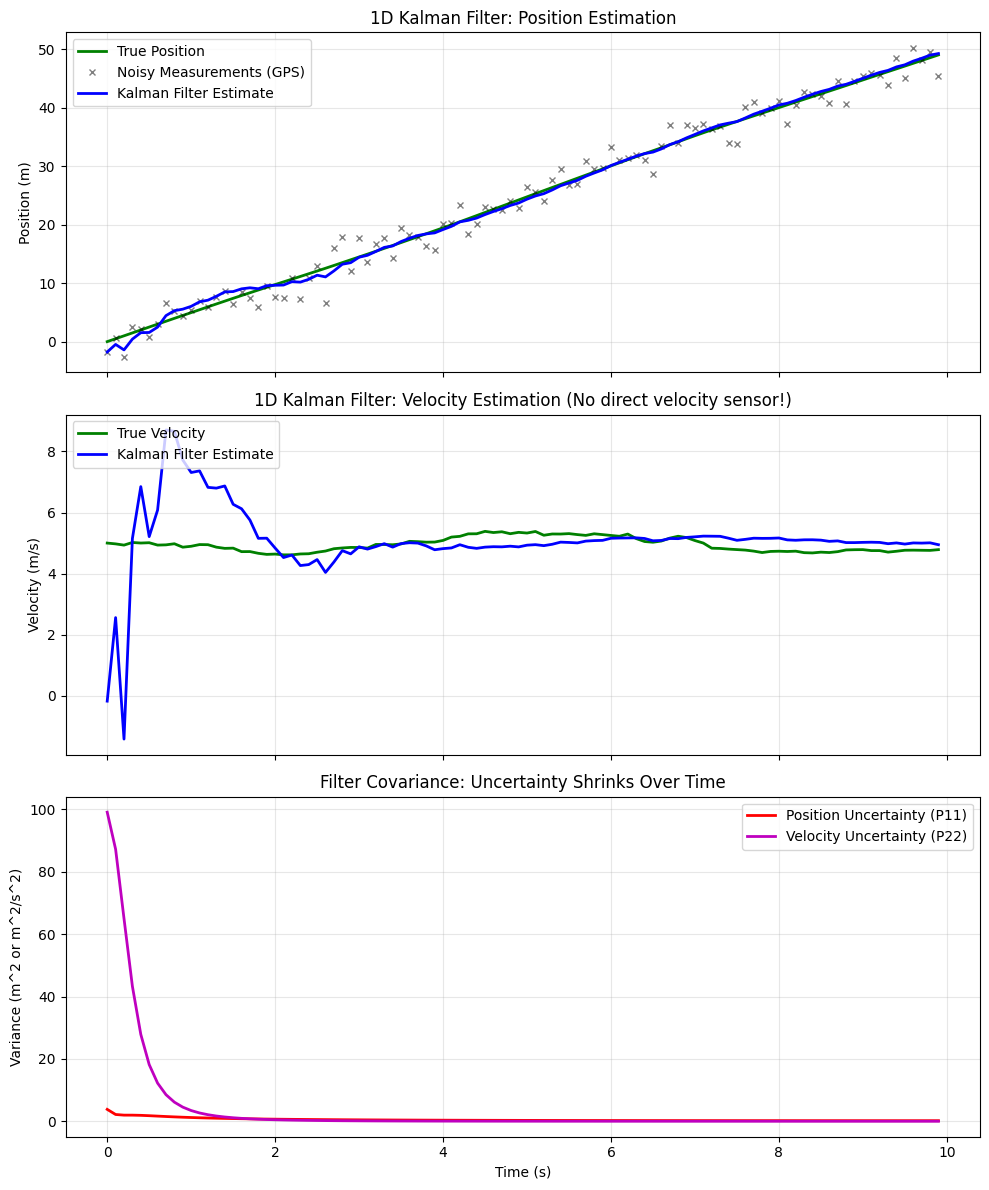

In [6]:
# =========================================================================
# 5. Visualization
# =========================================================================
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Plot 1: Position
ax1.plot(t, true_p, 'g-', label='True Position', linewidth=2)
ax1.plot(t, z, 'kx', markersize=4, label='Noisy Measurements (GPS)', alpha=0.5)
ax1.plot(t, x_hist[0, :], 'b-', label='Kalman Filter Estimate', linewidth=2)
ax1.set_ylabel('Position (m)')
ax1.set_title('1D Kalman Filter: Position Estimation')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Velocity (The Magic!)
ax2.plot(t, true_v, 'g-', label='True Velocity', linewidth=2)
ax2.plot(t, x_hist[1, :], 'b-', label='Kalman Filter Estimate', linewidth=2)
ax2.set_ylabel('Velocity (m/s)')
ax2.set_title('1D Kalman Filter: Velocity Estimation (No direct velocity sensor!)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Plot 3: Covariance (Uncertainty)
ax3.plot(t, P_hist[0, 0, :], 'r-', label='Position Uncertainty (P11)', linewidth=2)
ax3.plot(t, P_hist[1, 1, :], 'm-', label='Velocity Uncertainty (P22)', linewidth=2)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Variance (m^2 or m^2/s^2)')
ax3.set_title('Filter Covariance: Uncertainty Shrinks Over Time')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kalman_filter_1d.png', dpi=150)
print("Plot saved as 'kalman_filter_1d.png'")
plt.show()